# Salary Prediction using Polynomial Regression

**Assignment 3 — AI/ML**

**Objective:** Build a Polynomial Regression model to predict an employee's salary
from their position level, since the relationship between the two is non-linear.

**Dataset:** [Position Salaries Dataset (Kaggle)](https://www.kaggle.com/datasets/akram24/position-salaries)


## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)


In [2]:
# Load the dataset
df = pd.read_csv("position_salaries.csv")
df.head()


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Position  10 non-null     str  
 1   Level     10 non-null     int64
 2   Salary    10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 372.0 bytes


In [4]:
df.describe()


,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


**Feature identification**

| Type | Column |
|---|---|
| Input feature | `Level` (numeric encoding of position seniority, 1-10) |
| Target variable | `Salary` |
| Dropped | `Position` (text label that duplicates the information in `Level`) |


## Task 2: Data Preprocessing

In [5]:
# Check for missing values
df.isnull().sum()


Position    0
Level       0
Salary      0
dtype: int64

In [6]:
# Select the feature and target
X = df[['Level']]
y = df['Salary']

# 80% train / 20% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (8, 1)
Testing set shape: (2, 1)


> **Note:** this dataset only has 10 rows (one per position level), so an 80/20 split
> leaves just 2 points for testing. That's inherent to this particular dataset, not a
> preprocessing choice — with so few test points the evaluation metrics below should be
> read as illustrative rather than statistically robust.


## Task 3: Model Development

In [7]:
# Transform the input feature into polynomial features of degree 3:
# [Level] -> [1, Level, Level^2, Level^3]
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("Original shape:", X_train.shape, "-> Polynomial shape:", X_train_poly.shape)


Original shape: (8, 1) -> Polynomial shape: (8, 4)


In [8]:
# Train a Linear Regression model on the polynomial features
# (this is what makes it "Polynomial Regression": linear in the transformed features)
model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)

pd.DataFrame({'Level': X_test['Level'].values, 'Actual Salary': y_test.values, 'Predicted Salary': y_pred})


,Level,Actual Salary,Predicted Salary
0,9,500000,606335.600512
1,2,50000,84934.891292


## Task 4: Model Evaluation

In [9]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")


Mean Absolute Error (MAE): 70,635.25
Mean Squared Error (MSE): 6,263,853,282.86
Root Mean Squared Error (RMSE): 79,144.51
R-squared (R2 Score): 0.8763


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


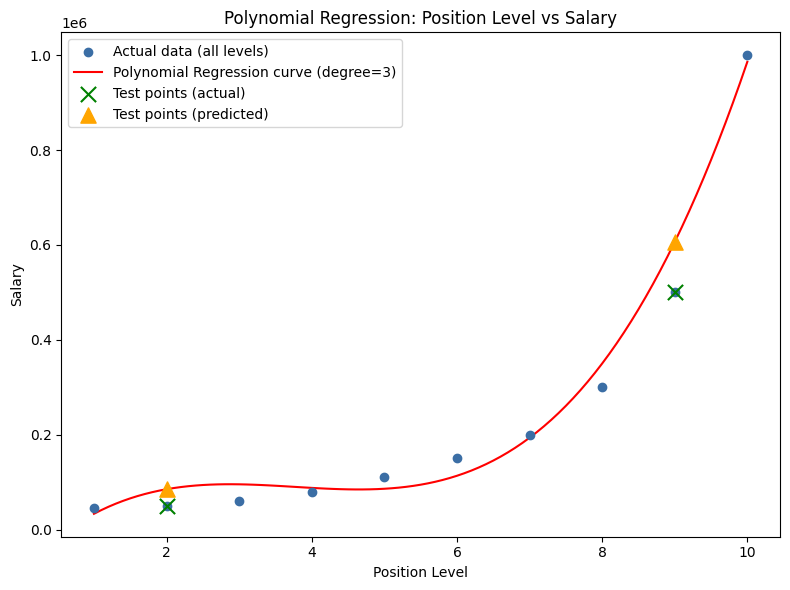

In [10]:
# Scatter plot of the original data + the fitted polynomial curve
X_grid = np.arange(X['Level'].min(), X['Level'].max() + 0.1, 0.1).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='#3b6ea5', label='Actual data (all levels)', zorder=3)
plt.plot(X_grid, y_grid_pred, color='red', label='Polynomial Regression curve (degree=3)')
plt.scatter(X_test, y_test, color='green', marker='x', s=120, label='Test points (actual)', zorder=4)
plt.scatter(X_test, y_pred, color='orange', marker='^', s=120, label='Test points (predicted)', zorder=4)
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.title('Polynomial Regression: Position Level vs Salary')
plt.legend()
plt.tight_layout()
plt.show()


### Observations

1. **The degree-3 polynomial curve tracks the sharp, non-linear jump in salary at the
   highest levels** (e.g., C-level and CEO salaries balloon compared to the roughly
   linear growth at lower levels) far better than a straight line could — this is the
   whole motivation for using Polynomial Regression on this dataset.
2. **R² ≈ 0.88 looks strong, but with only 2 test points it's a fragile estimate** — the
   test set includes level 10 (CEO, $1,000,000), the single most extreme and hardest
   point to predict, so a small change in which rows land in the test split would swing
   this metric a lot.
3. **Both test points were over-predicted** (Level 9 "C-level": actual $500,000 vs.
   predicted ≈ $606,336; Level 2 "Junior Consultant": actual $50,000 vs. predicted ≈
   $84,935) — a single smooth cubic has to fit both the flatter low end and the
   explosive high end of the curve, so it can overshoot in the middle/high-mid range
   even while capturing the overall non-linear shape well.


## Task 5: Conclusion

This project used Polynomial Regression (degree 3) to model the relationship between
an employee's position level and their salary. Because the growth in salary accelerates
sharply at senior levels rather than increasing at a constant rate, a plain Linear
Regression line would systematically underfit both ends of the data, while the cubic
polynomial curve bends to follow that acceleration and achieved an R² of about 0.88 on the
(very small) test set. The key difference between the two approaches is that Linear
Regression fits a single straight line (y = b0 + b1x) and can only capture constant-rate
relationships, whereas Polynomial Regression fits a curve (y = b0 + b1x + b2x^2 + b3x^3 +
...) by adding powers of the input feature, letting it capture accelerating or curving
relationships like this one while still being a linear model in its coefficients. The main
advantage of Polynomial Regression for this dataset is exactly that flexibility: it can
follow the steep, non-linear jump in salary at the highest position levels that a straight
line would badly misrepresent, at the cost of being more prone to overfitting on such a
small dataset if the degree is pushed too high.
